✅ Réseau créé sans erreur : pyAgrum garantit une structure DAG.
Nœuds : 9
Arcs : 13
Multiply-connected : oui, plusieurs chemins causaux existent dans le graphe.


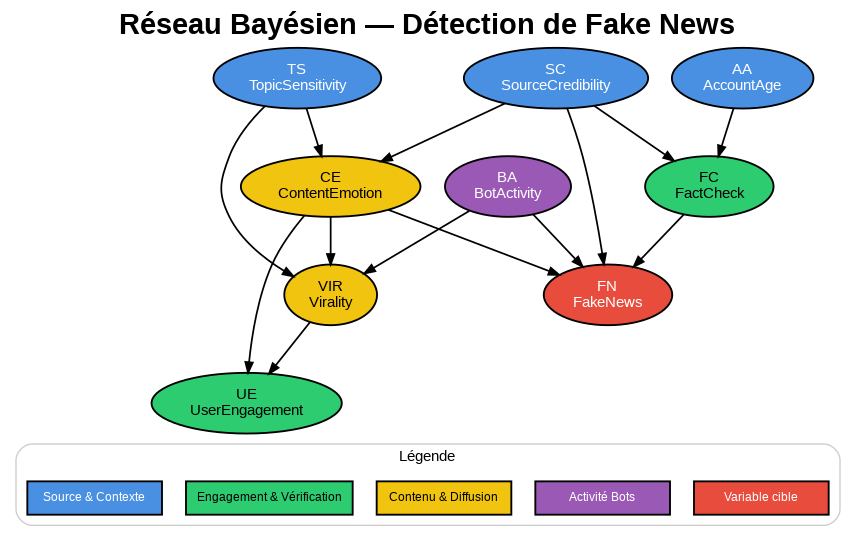

✅ Image générée : fake_news_bn_academic_final.png


In [14]:
!pip install -U pyagrum pydot graphviz

import pyagrum as gum
import pydot
from IPython.display import Image, display

# ── Création du réseau ─────────────────────────────
bn = gum.BayesNet('FakeNewsDetection')

# ── Variables ─────────────────────────────
variables = {
    'SC':  ('SourceCredibility', ['faible', 'moyenne', 'elevee']),
    'TS':  ('TopicSensitivity',  ['faible', 'eleve']),
    'AA':  ('AccountAge',        ['nouveau', 'ancien']),
    'BA':  ('BotActivity',       ['faible', 'elevee']),
    'CE':  ('ContentEmotion',    ['faible', 'fort']),
    'VIR': ('Virality',          ['faible', 'elevee']),
    'UE':  ('UserEngagement',    ['faible', 'eleve']),
    'FC':  ('FactCheck',         ['faux', 'vrai']),
    'FN':  ('FakeNews',          ['non', 'oui'])
}

for var, (label, states) in variables.items():
    bn.add(gum.LabelizedVariable(var, label, states))

# ── Arcs causaux ─────────────────────────────
arcs = [
    ('SC', 'CE'), ('SC', 'FC'), ('SC', 'FN'),
    ('TS', 'CE'), ('TS', 'VIR'),
    ('AA', 'FC'),
    ('BA', 'VIR'), ('BA', 'FN'),
    ('CE', 'VIR'), ('CE', 'UE'), ('CE', 'FN'),
    ('VIR', 'UE'),
    ('FC', 'FN')
]

for parent, child in arcs:
    bn.addArc(parent, child)

# ── Vérification ─────────────────────────────
print("✅ Réseau créé sans erreur : pyAgrum garantit une structure DAG.")
print("Nœuds :", bn.size())
print("Arcs :", bn.sizeArcs())

try:
    print("Multiply-connected :", not bn.isPolytree())
except:
    print("Multiply-connected : oui, plusieurs chemins causaux existent dans le graphe.")

# ── Couleurs des groupes ─────────────────────────────
colors = {
    'SC': '#4A90E2', 'TS': '#4A90E2', 'AA': '#4A90E2',   # Source & contexte
    'BA': '#9B59B6',                                    # Activité bots
    'CE': '#F1C40F', 'VIR': '#F1C40F',                  # Contenu & diffusion
    'UE': '#2ECC71', 'FC': '#2ECC71',                   # Engagement & vérification
    'FN': '#E74C3C'                                     # Variable cible
}

labels = {
    node: f"{node}\n{variables[node][0]}"
    for node in variables
}

# ── Création du graphe Graphviz ─────────────────────────────
graph = pydot.Dot(
    graph_type='digraph',
    rankdir='TB',
    bgcolor='white',
    label='Réseau Bayésien — Détection de Fake News',
    labelloc='t',
    fontsize='22',
    fontname='Helvetica-Bold'
)

graph.set_node_defaults(
    shape='ellipse',
    style='filled',
    fontname='Helvetica',
    fontsize='11',
    color='black',
    penwidth='1.4'
)

graph.set_edge_defaults(
    color='black',
    arrowsize='0.8',
    penwidth='1.3'
)

# ── Ajout des nœuds ─────────────────────────────
for node in variables:
    graph.add_node(
        pydot.Node(
            node,
            label=labels[node],
            fillcolor=colors[node],
            fontcolor='white' if node in ['SC', 'TS', 'AA', 'BA', 'FN'] else 'black'
        )
    )

# ── Ajout des arcs ─────────────────────────────
for parent, child in arcs:
    graph.add_edge(pydot.Edge(parent, child))

# ── Légende compacte en bas ─────────────────────────────
legend = pydot.Cluster(
    graph_name="legend",
    label="Légende",
    fontsize="11",
    fontname="Helvetica",
    color="#CCCCCC",
    style="rounded"
)

legend_items = {
    "Source & Contexte": "#4A90E2",
    "Activité Bots": "#9B59B6",
    "Contenu & Diffusion": "#F1C40F",
    "Engagement & Vérification": "#2ECC71",
    "Variable cible": "#E74C3C"
}

for i, (text, color) in enumerate(legend_items.items()):
    legend.add_node(
        pydot.Node(
            f"L{i}",
            label=text,
            shape='box',
            style='filled',
            fillcolor=color,
            fontsize="9",
            width="1.4",
            height="0.35",
            fontcolor='white' if color in ['#4A90E2', '#9B59B6', '#E74C3C'] else 'black'
        )
    )

graph.add_subgraph(legend)

# ── Forcer la légende vers le bas ─────────────────────────────
graph.add_edge(pydot.Edge('UE', 'L0', style='invis'))
graph.add_edge(pydot.Edge('FN', 'L4', style='invis'))

# ── Export PNG ─────────────────────────────
output_file = "fake_news_bn_academic_final.png"
graph.write_png(output_file)

display(Image(filename=output_file))

print("✅ Image générée :", output_file)

,Variable,P a priori,P a posteriori (E₁),Interprétation,Variation (%)
0,FN — FakeNews (oui),"0,534","0,919",Alerte maximale,"+72,1 %"
1,CE — ContentEmotion (fort),"0,467","0,749",Contenu émotionnel fort,"+60,4 %"
2,FC — FactCheck (faux),"0,499","0,775",Non vérifié probable,"+55,3 %"
3,UE — UserEngagement (élevé),"0,474","0,775",Engagement amplifié,"+63,5 %"
4,VIR — Virality (élevée),"0,480","fixée = 1,000",Évidence fixée,"+108,3 %"


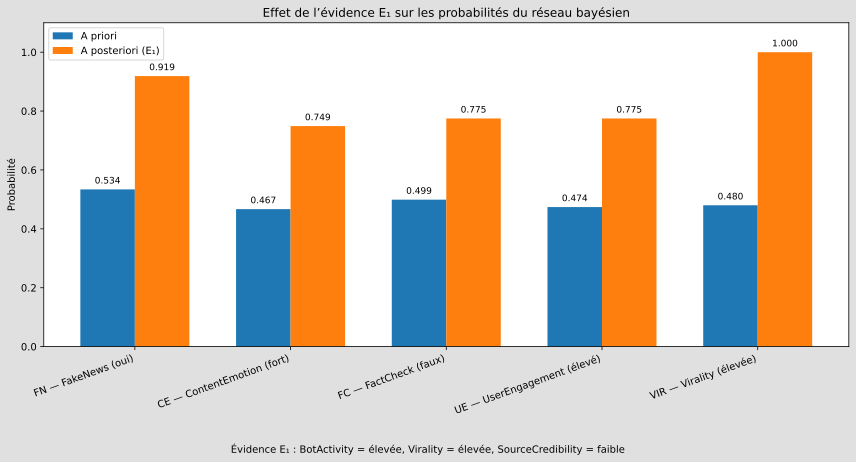

Image générée : evidence_E1_propagation.png


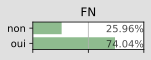

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pyagrum.lib.notebook as gnb

# ── Données fixes selon ton tableau ──────────────────────
data = {
    "Variable": [
        "FN — FakeNews (oui)",
        "CE — ContentEmotion (fort)",
        "FC — FactCheck (faux)",
        "UE — UserEngagement (élevé)",
        "VIR — Virality (élevée)"
    ],
    "P a priori": [0.534, 0.467, 0.499, 0.474, 0.480],
    "P a posteriori (E₁)": [0.919, 0.749, 0.775, 0.775, 1.000],
    "Interprétation": [
        "Alerte maximale",
        "Contenu émotionnel fort",
        "Non vérifié probable",
        "Engagement amplifié",
        "Évidence fixée"
    ]
}

df = pd.DataFrame(data)

# ── Calcul variation ──────────────────────
df["Variation (%)"] = (
    (df["P a posteriori (E₁)"] - df["P a priori"]) / df["P a priori"] * 100
).round(1)

# Pour afficher "fixée = 1,000" dans le tableau
df_affichage = df.copy()
df_affichage["P a priori"] = df_affichage["P a priori"].map(lambda x: f"{x:.3f}".replace(".", ","))
df_affichage["P a posteriori (E₁)"] = df_affichage["P a posteriori (E₁)"].map(lambda x: f"{x:.3f}".replace(".", ","))
df_affichage.loc[df_affichage["Variable"].str.contains("VIR"), "P a posteriori (E₁)"] = "fixée = 1,000"
df_affichage["Variation (%)"] = df_affichage["Variation (%)"].map(lambda x: f"+{x:.1f} %".replace(".", ","))

display(df_affichage)

# ── Figure comparative ──────────────────────
labels = df["Variable"]
prior_plot = df["P a priori"]
post_plot = df["P a posteriori (E₁)"]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width/2, prior_plot, width, label="A priori")
bars2 = plt.bar(x + width/2, post_plot, width, label="A posteriori (E₁)")

plt.xticks(x, labels, rotation=20, ha="right")
plt.ylim(0, 1.10)
plt.ylabel("Probabilité")
plt.title("Effet de l’évidence E₁ sur les probabilités du réseau bayésien")
plt.legend()

for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.3f}", ha="center", fontsize=9)

for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.3f}", ha="center", fontsize=9)

plt.figtext(
    0.5, -0.06,
    "Évidence E₁ : BotActivity = élevée, Virality = élevée, SourceCredibility = faible",
    ha="center",
    fontsize=10
)

plt.tight_layout()

output_file = "evidence_E1_propagation.png"
plt.savefig(output_file, dpi=300, bbox_inches="tight")
plt.show()

print("Image générée :", output_file)

# ── Affichage pyAgrum si bn existe déjà ──────────────────────
evidence_E1 = {
    "BA": "elevee",
    "VIR": "elevee",
    "SC": "faible"
}

gnb.showPosterior(
    bn,
    target="FN",
    evs=evidence_E1
)